## Local notebook setup

This notebook is intended to be run **locally** from the project root (so relative paths like `data/processed/...` work).

Data locations used in this notebook:
- Raw inputs (optional here): `data/raw/`
- Processed joined dataset (required): `data/processed/hotels_with_cities-2.parquet`


In [ ]:
# Ensure imports work when running locally.
# Run this notebook from the repo root (the folder that contains `src/` and `data/`).

import sys
from pathlib import Path

PROJECT = Path.cwd()
sys.path.insert(0, str(PROJECT))

import src
print("Imported src from:", Path(src.__file__).resolve())

## Verify local files exist

This step confirms the processed dataset exists locally before we load it.

Raw inputs under `data/raw/` are optional here (only needed if you want to regenerate processed outputs).

In [ ]:
from pathlib import Path

PROCESSED = Path("data/processed/hotels_with_cities-2.parquet")
print("processed exists:", PROCESSED.is_file(), PROCESSED)

RAW_HOTELS = Path("data/raw/hotels.csv")
RAW_WORLD = Path("data/raw/worldcitiespop.csv")
print("raw hotels exists:", RAW_HOTELS.is_file(), RAW_HOTELS)
print("raw world cities exists:", RAW_WORLD.is_file(), RAW_WORLD)

In [ ]:
# Install project requirements (local)
# If you already have dependencies installed, you can skip this.

!python3 -m pip install -q -r requirements.txt

## Data wrangling (already completed)

The data-wrangling pipeline (cleaning + standardization + feature creation + Hotels × World Cities join) has already been run, and its output is saved locally as:
- `data/processed/hotels_with_cities-2.parquet`

That processed dataset is what we will use for the rest of this notebook.

If you ever need to regenerate processed outputs from the raw CSVs, you can run the pipeline command shown next—but it is **not needed** for the normal workflow.

In [ ]:
# Do NOT run for the normal workflow.
# The processed dataset is already available at `data/processed/hotels_with_cities-2.parquet`.

RUN_CLEANING = False

if RUN_CLEANING:
    !python3 scripts/pipeline/run_cleaning.py \
        --output-dir data/processed \
        --format parquet \
        --chunksize 50000 \
        --progress-every 50000
else:
    print("Skipping cleaning pipeline (processed dataset already exists).")

## Use the processed dataset

Now we use the processed dataset created above (`data/processed/hotels_with_cities-2.parquet`) and summarize what it contains.

**This cell outputs:**
- Dataset **size** (rows, columns)
- A **5-row preview** (what one hotel record looks like)
- The **top 12 columns by % missing** (coverage snapshot)
- The **distribution of hotel star ratings** (counts per `hotel_star_rating`)

In [ ]:
from pathlib import Path
import pandas as pd

joined = Path("data/processed/hotels_with_cities-2.parquet")
if not joined.is_file():
    raise FileNotFoundError(
        f"Expected processed Parquet at {joined}. "
        "If you saved it under a different name/location, update the path here."
    )

df = pd.read_parquet(joined)

# Normalize any alias column names to the canonical schema.
try:
    from src.modeling.feature_matrix import normalize_engineered_column_names

    df = normalize_engineered_column_names(df)
except Exception:
    pass

print("processed Parquet:", joined)
print("rows:", len(df), "cols:", df.shape[1])

display(df.head(5))

na_rate = (df.isna().mean() * 100).sort_values(ascending=False)
display(na_rate.head(12).to_frame(name="% missing"))

if "hotel_star_rating" not in df.columns:
    raise KeyError("Expected column 'hotel_star_rating' not found in processed dataset.")

display(df["hotel_star_rating"].value_counts(dropna=False).sort_index().to_frame(name="count"))

## Modeling (local)

This section trains and compares multiple regression models for hotel rating prediction.

Supported models:
- `linear`, `ridge`, `lasso`, `rf`, `xgb`

Metrics reported:
- RMSE, MAE, R²
- hit rates: `|error| <= 0.5` and `|error| <= 1.0`


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
OUT_DIR = Path("outputs/model_artifacts_local")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Use a sample for speed while iterating. Set to None for full dataset.
SAMPLE_ROWS = 100_000
RANDOM_STATE = 42

print("project root:", PROJECT_ROOT)
print("artifacts dir:", OUT_DIR)
print("sample rows:", SAMPLE_ROWS)


In [ ]:
# Train two baseline models (fast examples).
# This writes metrics.json and model artifacts under OUT_DIR.

sample_arg = [] if SAMPLE_ROWS is None else ["--sample", str(SAMPLE_ROWS)]

!python3 scripts/modeling/train_baseline_model.py --project-root "{PROJECT_ROOT}" --model linear --out-dir "{OUT_DIR / 'linear'}" --random-state {RANDOM_STATE} {*sample_arg}
!python3 scripts/modeling/train_baseline_model.py --project-root "{PROJECT_ROOT}" --model rf --out-dir "{OUT_DIR / 'rf'}" --random-state {RANDOM_STATE} {*sample_arg}


In [ ]:
# Run a small comparison set and summarize metrics.

import json
import subprocess
import pandas as pd

RUNS_DIR = OUT_DIR / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

models_to_run = [
    ("linear", []),
    ("ridge", ["--ridge-alpha", "10"]),
    ("lasso", ["--lasso-alpha", "0.001"]),
    ("rf", ["--rf-estimators", "200", "--rf-max-depth", "20"]),
]

for model_name, extra_args in models_to_run:
    out_dir = RUNS_DIR / model_name
    out_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        "python3",
        "scripts/modeling/train_baseline_model.py",
        "--project-root",
        str(PROJECT_ROOT),
        "--model",
        model_name,
        "--out-dir",
        str(out_dir),
        "--random-state",
        str(RANDOM_STATE),
    ]
    if SAMPLE_ROWS is not None:
        cmd.extend(["--sample", str(SAMPLE_ROWS)])
    cmd.extend(extra_args)

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)

summary_rows = []
for model_name, _ in models_to_run:
    metrics_path = RUNS_DIR / model_name / "metrics.json"
    if not metrics_path.exists():
        continue
    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    summary_rows.append(
        {
            "model": model_name,
            "rows": metrics["rows"],
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
            "within_0_5": metrics["within_0_5"],
            "within_1_0": metrics["within_1_0"],
            "tuned": metrics.get("tuned", False),
        }
    )

results_df = pd.DataFrame(summary_rows).sort_values(by="rmse", ascending=True)
results_df

## Optional: hypothesis testing (permutation-based)

This runs a simulation-based test to check whether observed relationships for selected features are stronger than chance (correlation evidence, not causation).


In [ ]:
import subprocess
from pathlib import Path

hypo_out = OUT_DIR / "hypothesis_tests.json"
cmd = [
    "python3",
    "scripts/modeling/permutation_hypothesis_tests.py",
    "--project-root",
    str(PROJECT_ROOT),
    "--out",
    str(hypo_out),
    "--n-permutations",
    "200",
    "--random-state",
    str(RANDOM_STATE),
]
if SAMPLE_ROWS is not None:
    cmd.extend(["--sample", str(SAMPLE_ROWS)])

print("Running:", " ".join(cmd))
subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
print("Wrote:", hypo_out)


## Optional: XGBoost (local note)

On macOS, XGBoost often requires the OpenMP runtime (**OpenMP `libomp`**).

If you see an error about `libomp.dylib` missing, install it and reinstall XGBoost:

- `brew install libomp`
- restart your terminal/kernel
- `python3 -m pip install -U xgboost`

If XGBoost is not available locally, you can still run `linear`, `ridge`, `lasso`, and `rf` here, and run `xgb` in Kaggle.


In [ ]:
# Optional local XGBoost run (guarded).

RUN_XGB = False

if RUN_XGB:
    try:
        import xgboost  # noqa: F401

        print("xgboost available")
    except Exception as e:
        raise RuntimeError(
            "xgboost is not available locally. On macOS, install OpenMP runtime (libomp) then reinstall xgboost."
        ) from e

    import subprocess

    out_dir = RUNS_DIR / "xgb"
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "python3",
        "scripts/modeling/train_baseline_model.py",
        "--project-root",
        str(PROJECT_ROOT),
        "--model",
        "xgb",
        "--out-dir",
        str(out_dir),
        "--random-state",
        str(RANDOM_STATE),
        "--xgb-estimators",
        "300",
        "--xgb-max-depth",
        "8",
        "--xgb-learning-rate",
        "0.05",
    ]
    if SAMPLE_ROWS is not None:
        cmd.extend(["--sample", str(SAMPLE_ROWS)])

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
else:
    print("RUN_XGB is False — skipping XGBoost locally.")


# Exploratory Data Analysis

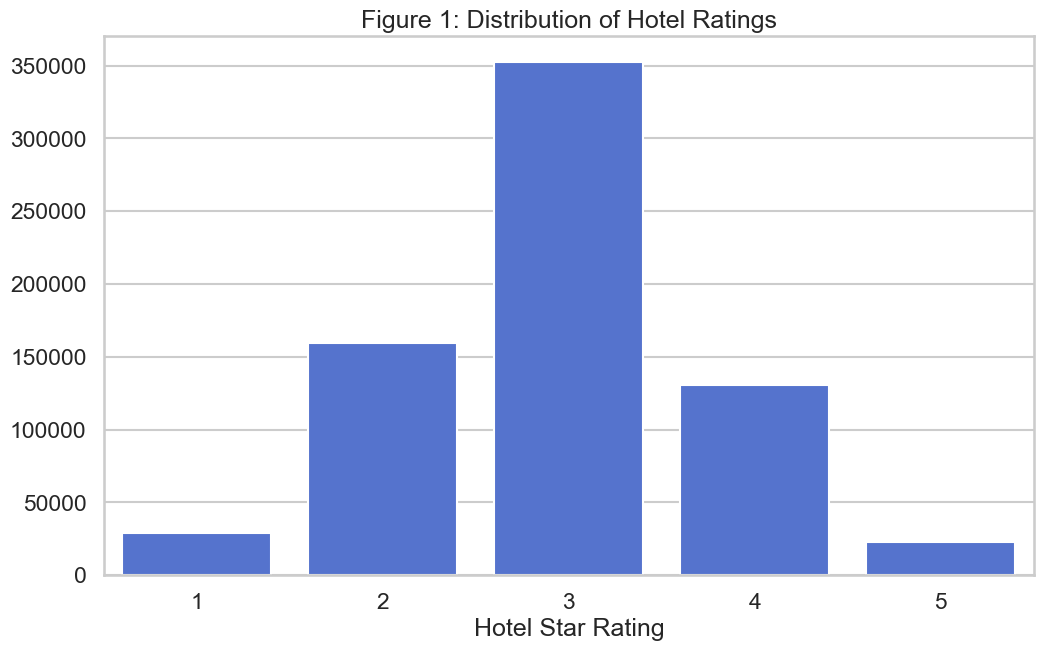

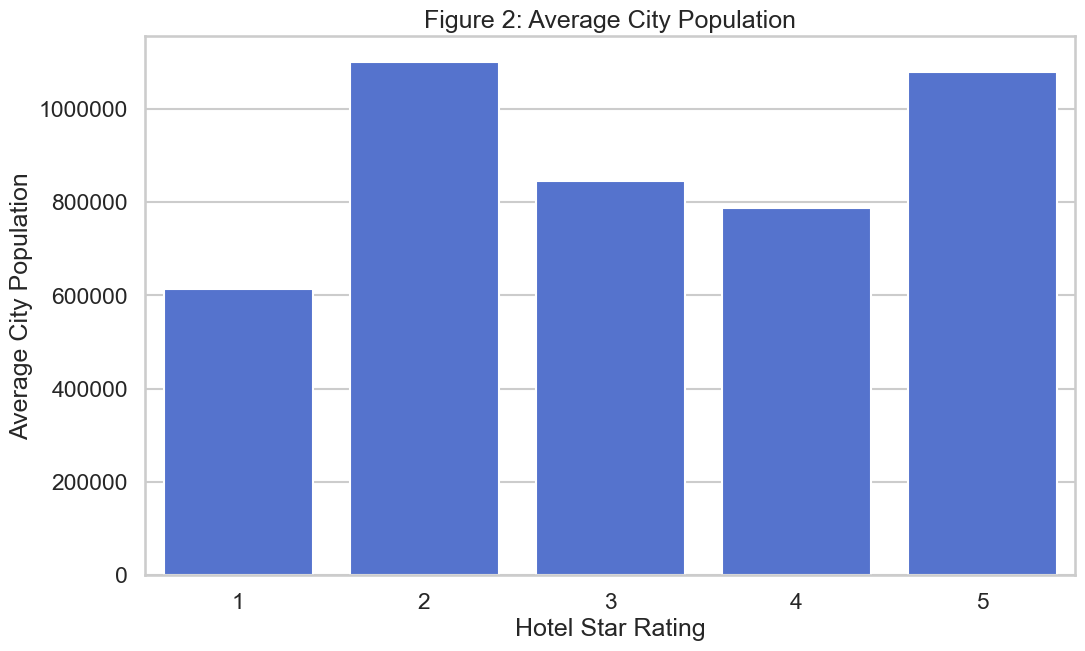

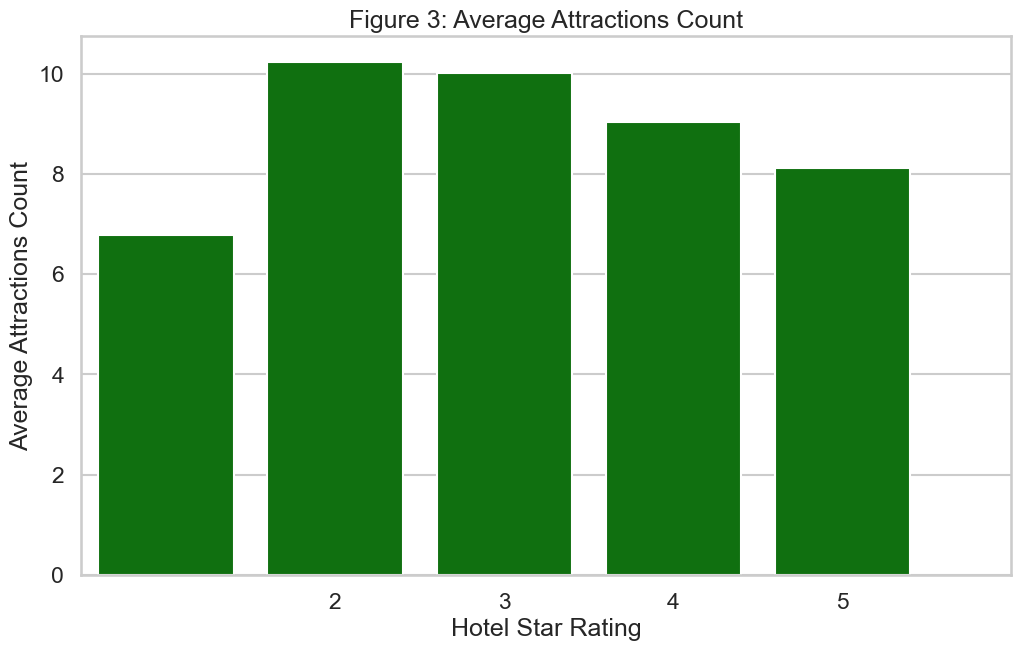

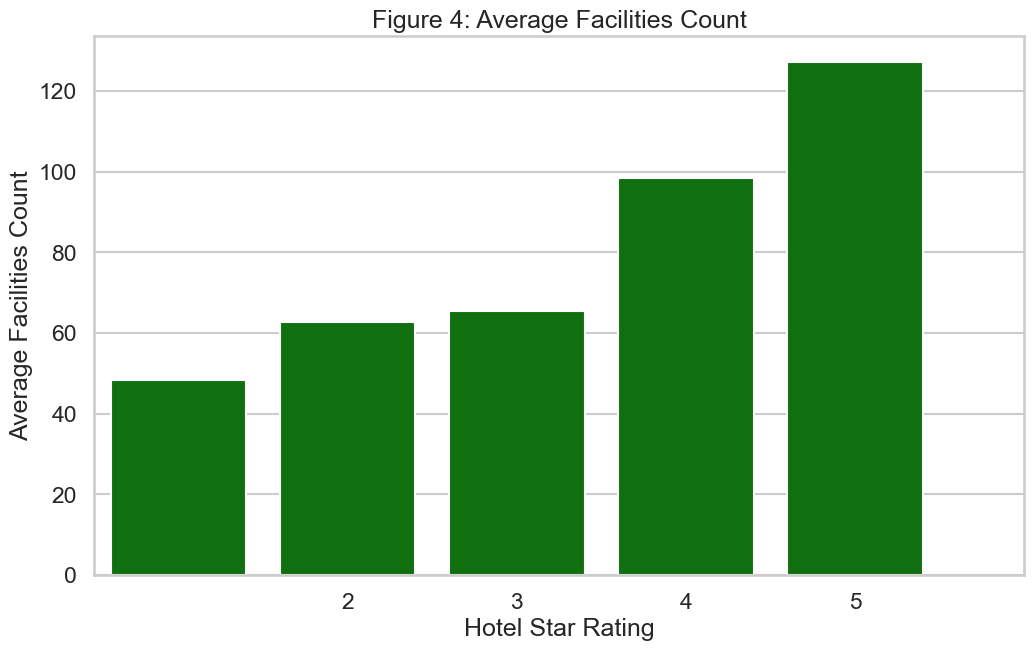

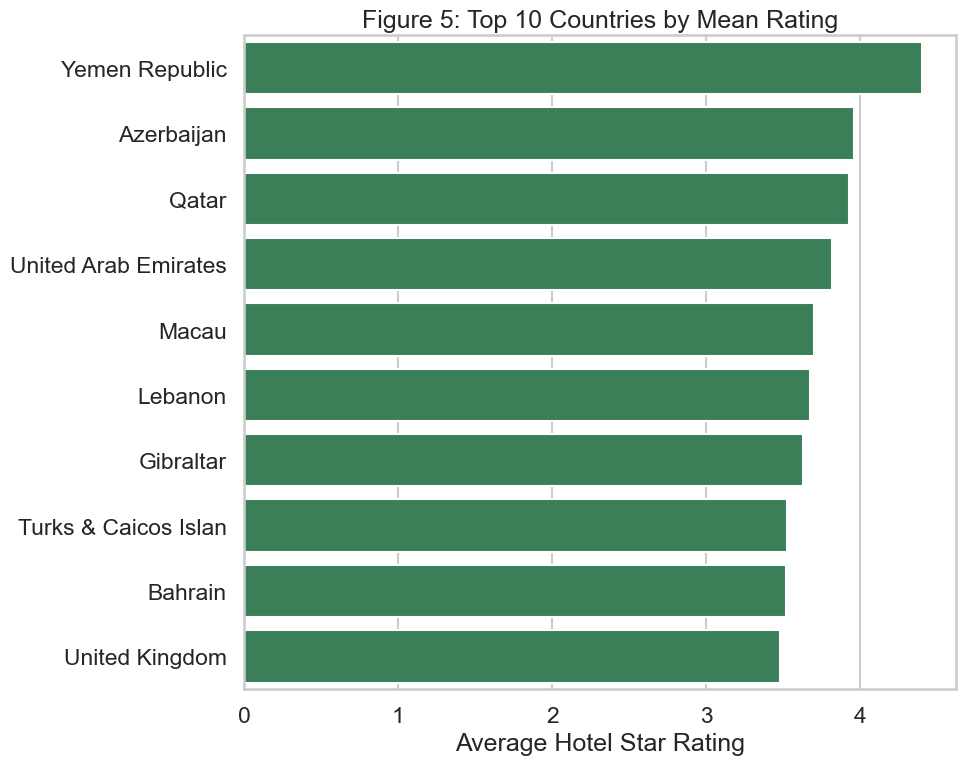

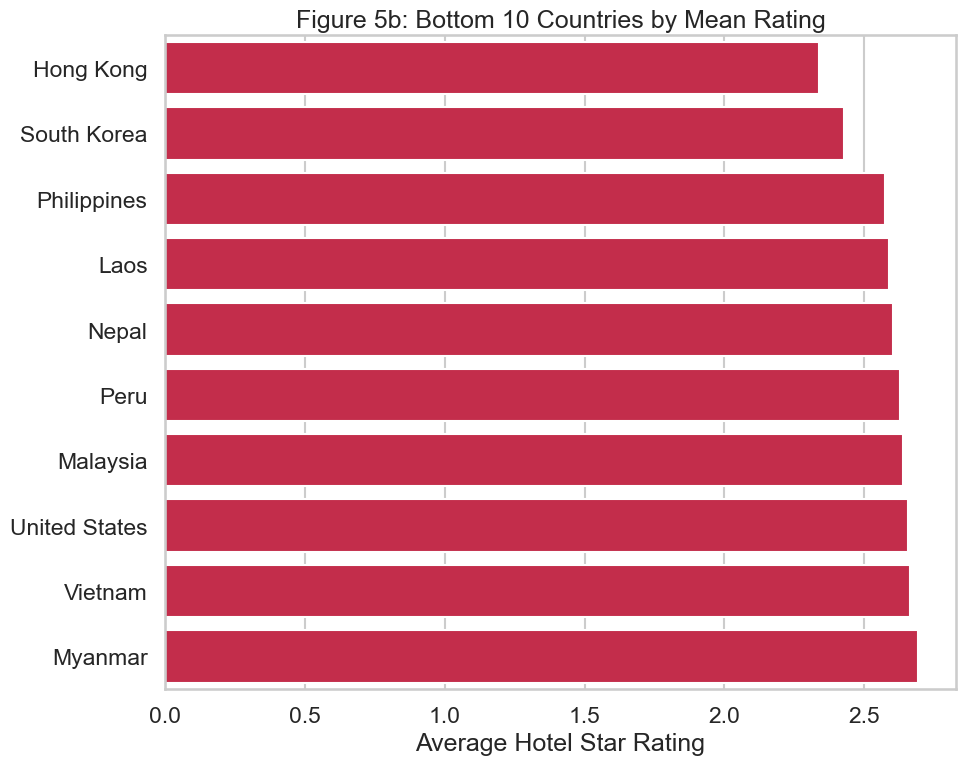

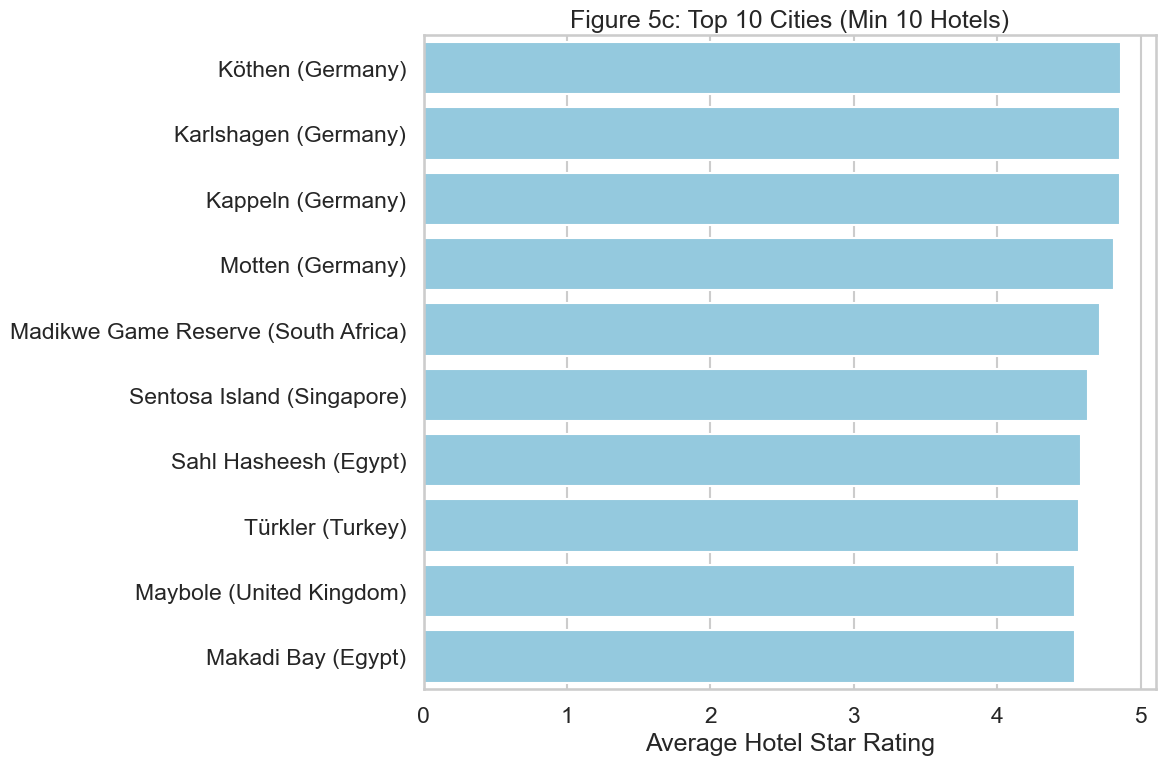

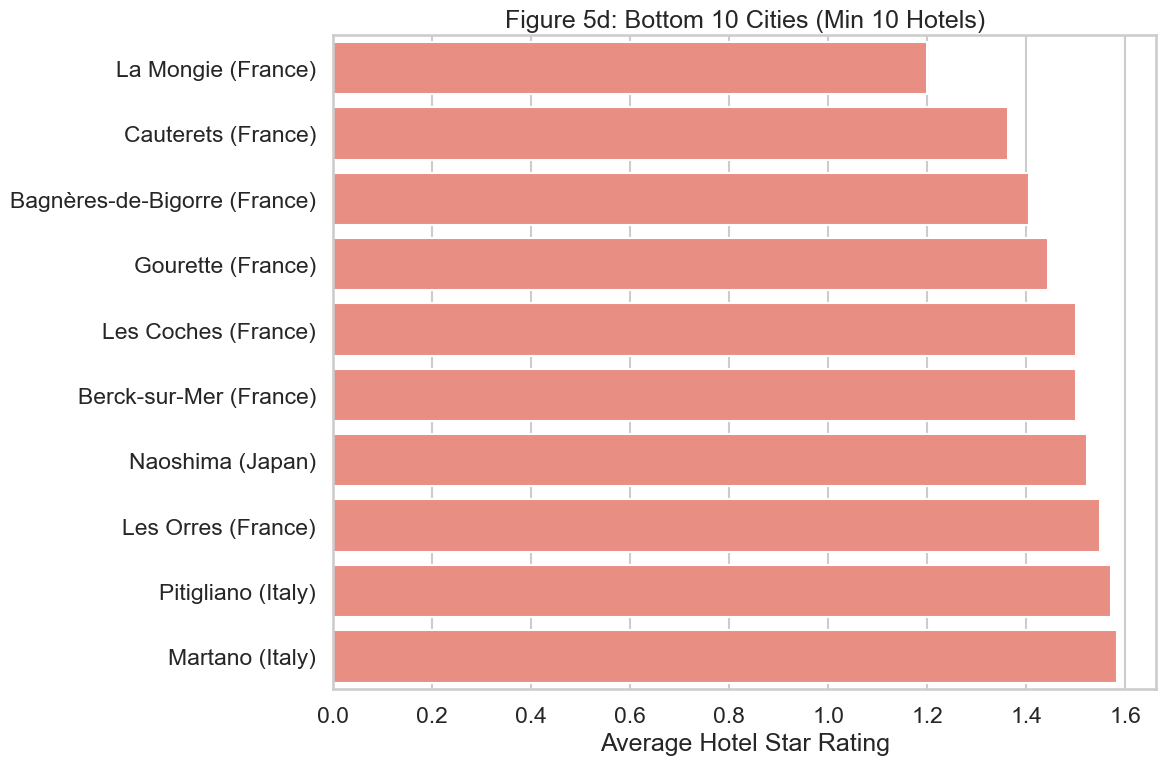

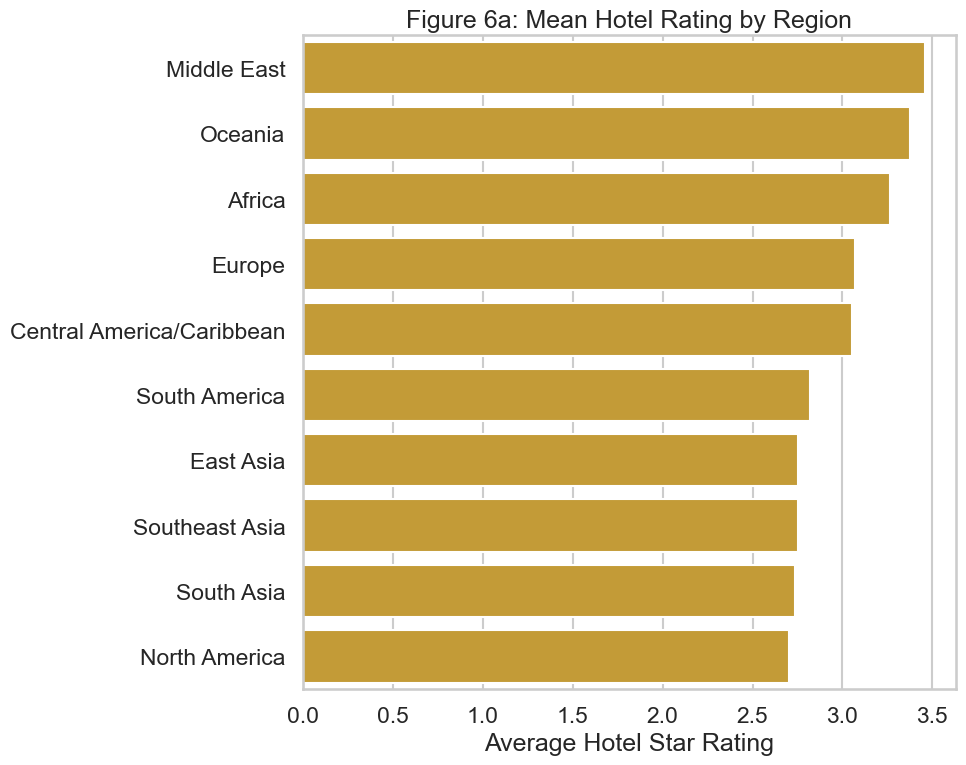

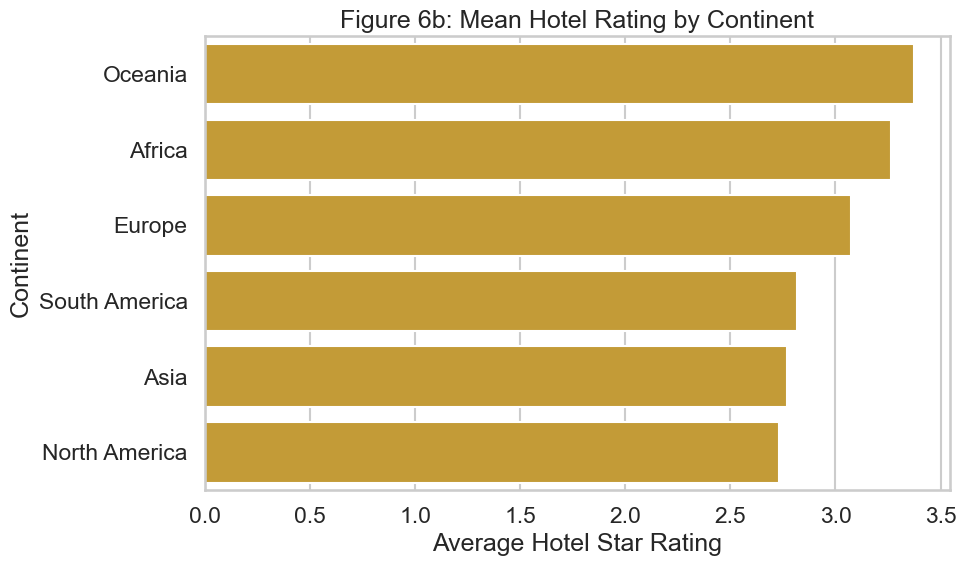

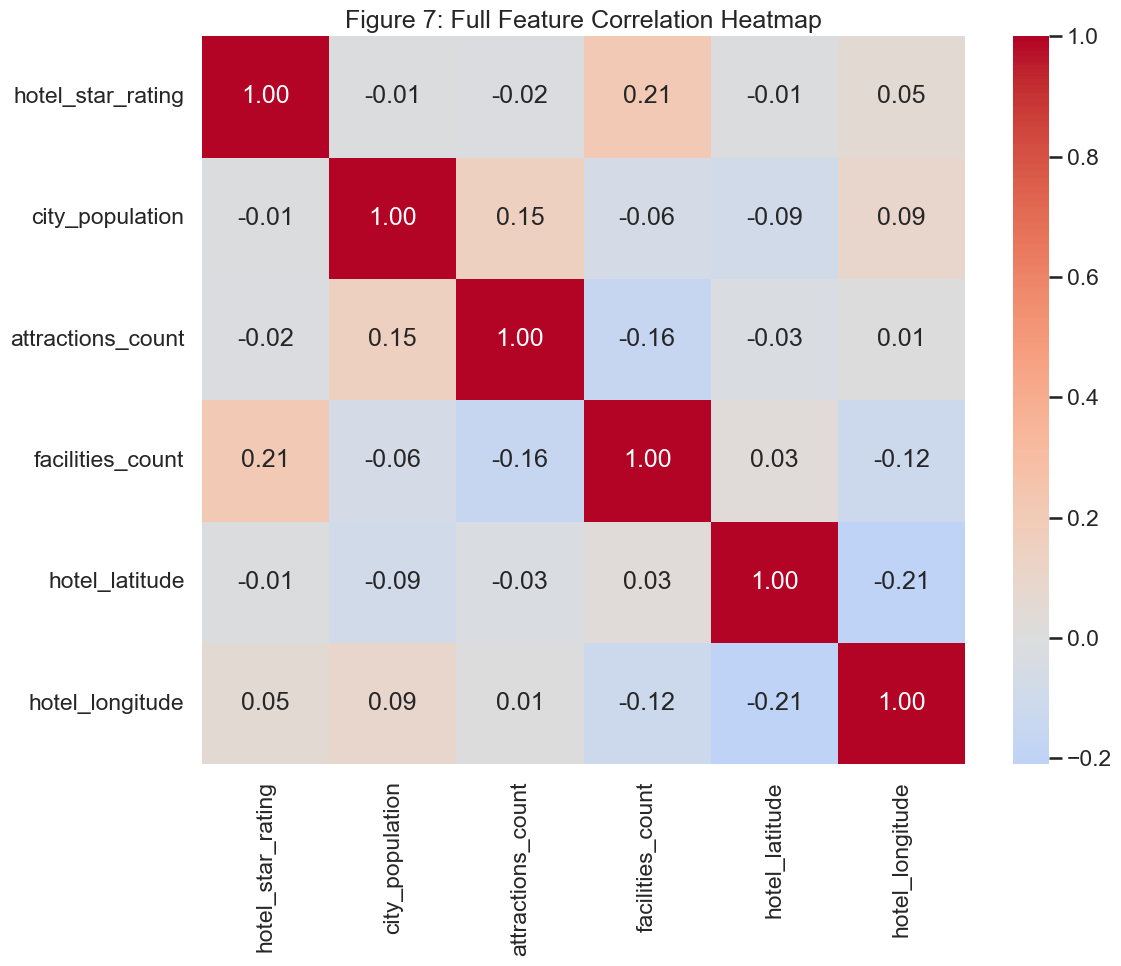

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_parquet('../data/processed/hotels_with_cities-2.parquet')

# --- 1. Refined Sub-Region Mapping ---
region_map = {
    # NORTH AMERICA
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    
    # SOUTH AMERICA
    'Argentina': 'South America', 'Bolivia': 'South America', 'Brazil': 'South America', 
    'Chile': 'South America', 'Colombia': 'South America', 'Ecuador': 'South America', 
    'Paraguay': 'South America', 'Peru': 'South America', 'Uruguay': 'South America', 
    'Venezuela': 'South America',

    # CENTRAL AMERICA & CARIBBEAN
    'Antigua': 'Central America/Caribbean', 'Aruba': 'Central America/Caribbean', 'Bahamas': 'Central America/Caribbean',
    'Barbados': 'Central America/Caribbean', 'Costa Rica': 'Central America/Caribbean', 'Dominican Republic': 'Central America/Caribbean',
    'Grenada': 'Central America/Caribbean', 'Guadeloupe': 'Central America/Caribbean', 'Guatemala': 'Central America/Caribbean',
    'Jamaica': 'Central America/Caribbean', 'Panama': 'Central America/Caribbean', 'Puerto Rico': 'Central America/Caribbean',
    'St Kitts & Nevis': 'Central America/Caribbean', 'St Lucia': 'Central America/Caribbean', 
    'St Vincent & Grenadi': 'Central America/Caribbean', 'Trinidad & Tobago': 'Central America/Caribbean',
    'Turks & Caicos Islan': 'Central America/Caribbean', 'Virgin Islands (USA)': 'Central America/Caribbean',

    # EAST ASIA
    'China': 'East Asia', 'Hong Kong': 'East Asia', 'Japan': 'East Asia', 
    'Macau': 'East Asia', 'Mongolia': 'East Asia', 'South Korea': 'East Asia', 'Taiwan': 'East Asia',

    # SOUTHEAST ASIA
    'Brunei Darussalam': 'Southeast Asia', 'Cambodia': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Laos': 'Southeast Asia', 'Malaysia': 'Southeast Asia', 'Myanmar': 'Southeast Asia',
    'Philippines': 'Southeast Asia', 'Singapore': 'Southeast Asia', 'Thailand': 'Southeast Asia',
    'Vietnam': 'Southeast Asia',

    # SOUTH ASIA
    'India': 'South Asia', 'Nepal': 'South Asia', 'Sri Lanka': 'South Asia',

    # MIDDLE EAST
    'Bahrain': 'Middle East', 'Israel': 'Middle East', 'Jordan': 'Middle East', 'Kuwait': 'Middle East',
    'Lebanon': 'Middle East', 'Oman': 'Middle East', 'Qatar': 'Middle East', 'Saudi Arabia': 'Middle East',
    'Turkey': 'Middle East', 'United Arab Emirates': 'Middle East', 'Yemen Republic': 'Middle East',

    # EUROPE
    'Albania': 'Europe', 'Andorra': 'Europe', 'Austria': 'Europe', 'Azerbaijan': 'Europe',
    'Belarus': 'Europe', 'Belgium': 'Europe', 'Bosnia Herzegovina': 'Europe', 'Bulgaria': 'Europe',
    'Croatia': 'Europe', 'Cyprus': 'Europe', 'Czech Republic': 'Europe', 'Denmark': 'Europe',
    'Estonia': 'Europe', 'Finland': 'Europe', 'France': 'Europe', 'Germany': 'Europe',
    'Gibraltar': 'Europe', 'Greece': 'Europe', 'Hungary': 'Europe', 'Iceland': 'Europe',
    'Ireland(Republic of)': 'Europe', 'Italy': 'Europe', 'Latvia': 'Europe', 'Liechtenstein': 'Europe',
    'Lithuania': 'Europe', 'Luxembourg': 'Europe', 'Malta': 'Europe', 'Monaco': 'Europe',
    'Netherlands': 'Europe', 'Norway': 'Europe', 'Poland': 'Europe', 'Portugal': 'Europe',
    'Romania': 'Europe', 'Russia': 'Europe', 'Russian Federation': 'Europe', 'San Marino': 'Europe',
    'Serbia': 'Europe', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Ukraine': 'Europe', 'United Kingdom': 'Europe',

    # AFRICA
    'Botswana': 'Africa', 'Cameroon': 'Africa', 'Egypt': 'Africa', 'Ethiopia': 'Africa',
    'Kenya': 'Africa', 'Libya': 'Africa', 'Mauritius': 'Africa', 'Morocco': 'Africa',
    'Namibia': 'Africa', 'Nigeria': 'Africa', 'Senegal': 'Africa', 'Seychelles': 'Africa',
    'South Africa': 'Africa', 'Tanzania': 'Africa', 'Tunisia': 'Africa', 'Zambia': 'Africa',
    'Zimbabwe': 'Africa', 'Swaziland': 'Africa',

    # OCEANIA
    'Australia': 'Oceania', 'Cook Islands': 'Oceania', 'Fiji': 'Oceania', 'Guam': 'Oceania',
    'New Caledonia': 'Oceania', 'New Zealand': 'Oceania', 'Northern Mariana Isl': 'Oceania',
    'Palau': 'Oceania', 'Samoa': 'Oceania', 'Tonga': 'Oceania', 'Vanuatu': 'Oceania',
    'French Polynesia': 'Oceania'
}

# --- Map Sub-Regions to Main Continents ---
continent_map = {
    'North America': 'North America',
    'South America': 'South America',
    'Central America/Caribbean': 'North America', 
    'East Asia': 'Asia',
    'Southeast Asia': 'Asia',
    'South Asia': 'Asia',
    'Middle East': 'Asia',
    'Europe': 'Europe',
    'Africa': 'Africa',
    'Oceania': 'Oceania'
}

df['sub_region'] = df['countyName'].map(region_map).fillna('Other')
df['continent'] = df['sub_region'].map(continent_map).fillna('Other')

# Global styling
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# --- 2. Calculations ---
sub_region_stats = df.groupby('sub_region')['hotel_star_rating'].mean().sort_values(ascending=False)
continent_stats = df.groupby('continent')['hotel_star_rating'].mean().sort_values(ascending=False)
country_stats = df.groupby('countyName')['hotel_star_rating'].mean().dropna()
city_stats = df.groupby(['cityName', 'countyName'])['hotel_star_rating'].agg(['mean', 'count']).dropna().reset_index()
city_stats['city_label'] = city_stats['cityName'] + " (" + city_stats['countyName'] + ")"

reliable_cities = city_stats[city_stats['count'] >= 10]

top_10_countries = country_stats.sort_values(ascending=False).head(10)
worst_10_countries = country_stats.sort_values(ascending=True).head(10)
top_10_cities = reliable_cities.sort_values(by='mean', ascending=False).head(10)
worst_10_cities = reliable_cities.sort_values(by='mean', ascending=True).head(10)

# --- GENERATE PLOTS ---

# Figure 1: Distribution
plt.figure()
sns.countplot(data=df, x='hotel_star_rating', color='royalblue')
plt.title('Figure 1: Distribution of Hotel Ratings')
plt.xlabel('Hotel Star Rating')
plt.ylabel('')
# plt.savefig('eda_1_rating_imbalance.png')

# Figure 2
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='city_population', estimator=np.mean, errorbar=None, color='royalblue')

plt.ticklabel_format(style='plain', axis='y')
plt.title('Figure 2: Average City Population')
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average City Population')
# plt.savefig('eda_2_bar_pop.png')

# Figure 3
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='attractions_count', estimator=np.mean, errorbar=None, color='green')
plt.title('Figure 3: Average Attractions Count')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average Attractions Count')
# plt.savefig('eda_3_rating_vs_attractions.png')

# Figure 4
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='facilities_count', estimator=np.mean, errorbar=None, color='green')
plt.title('Figure 4: Average Facilities Count')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average Facilities Count')
# plt.savefig('eda_4_rating_vs_facilities.png')

# Figure 5: Top 10 Countries (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=top_10_countries.index, x=top_10_countries.values, color='seagreen', orient='h')
plt.title('Figure 5: Top 10 Countries by Mean Rating')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
# plt.savefig('eda_5_top_countries.png')

# Figure 5b: Worst 10 Countries (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=worst_10_countries.index, x=worst_10_countries.values, color='crimson', orient='h')
plt.title('Figure 5b: Bottom 10 Countries by Mean Rating')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
# plt.savefig('eda_5b_worst_countries.png')

# Figure 5c: Top 10 Cities (Horizontal)
plt.figure(figsize=(12, 8))
sns.barplot(y=top_10_cities['city_label'], x=top_10_cities['mean'], color='skyblue', orient='h')
plt.title('Figure 5c: Top 10 Cities (Min 10 Hotels)')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
# plt.savefig('eda_5c_top_cities.png')

# Figure 5d: Worst 10 Cities (Horizontal)
plt.figure(figsize=(12, 8))
sns.barplot(y=worst_10_cities['city_label'], x=worst_10_cities['mean'], color='salmon', orient='h')
plt.title('Figure 5d: Bottom 10 Cities (Min 10 Hotels)')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
# plt.savefig('eda_5d_worst_cities.png')

# Figure 6a: Sub-Region (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=sub_region_stats.index, x=sub_region_stats.values, color='goldenrod', orient='h')
plt.title('Figure 6a: Mean Hotel Rating by Region')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
# plt.savefig('eda_6a_rating_by_sub_region.png')

# Figure 6b: Rating by Continent
plt.figure(figsize=(10, 6))
sns.barplot(y=continent_stats.index, x=continent_stats.values, color='goldenrod', orient='h')
plt.title('Figure 6b: Mean Hotel Rating by Continent')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('Continent')
plt.tight_layout()
# plt.savefig('eda_6b_rating_by_continent.png')

# Figure 7: Correlation
numeric_cols_all = [
    'hotel_star_rating', 
    'city_population', 
    'attractions_count', 
    'facilities_count',
    'hotel_latitude', 
    'hotel_longitude'
]

# Calculate the correlation matrix
corr_all = df[numeric_cols_all].corr()

# Create the plot without a mask to show the full square
fig, ax = plt.subplots(figsize=(12, 10))

# Draw the full square heatmap
sns.heatmap(
    corr_all, 
    annot=True, 
    cmap='coolwarm', 
    center=0, 
    fmt='.2f', 
    ax=ax
)

ax.set_title('Figure 7: Full Feature Correlation Heatmap')
plt.tight_layout()
# plt.savefig('eda_7_square_heatmap.png')

plt.show()

# Expanded Exploratory Data Analysis and Visualizations

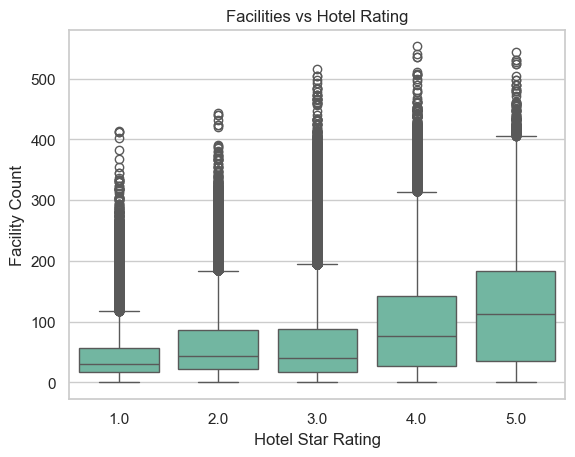

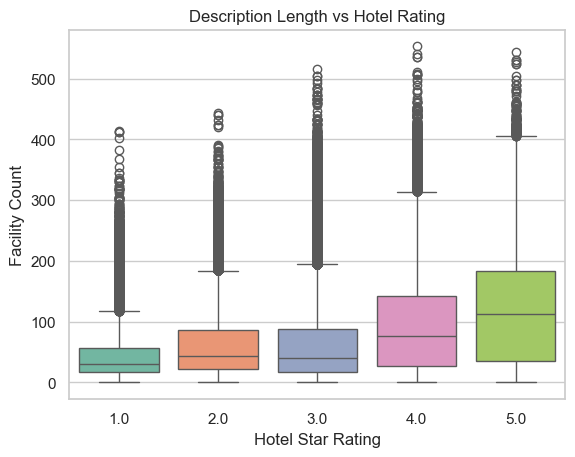

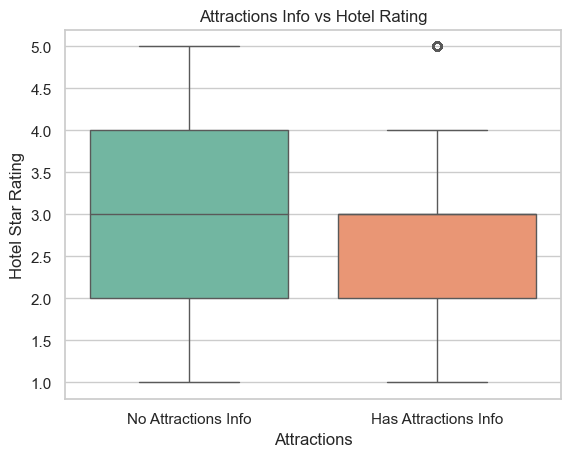

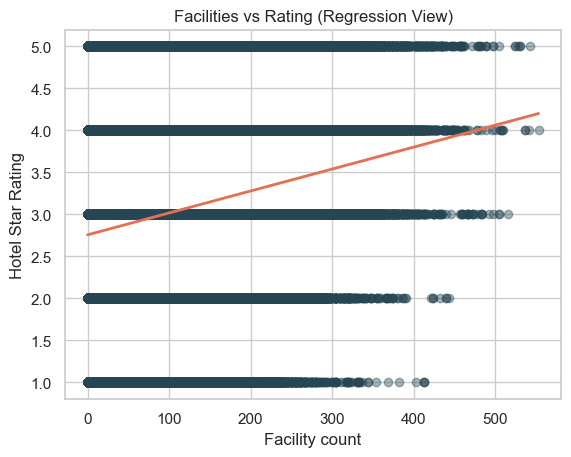

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Load raw data once
df = pd.read_csv("../data/raw/hotels.csv", encoding="latin-1")
df.columns = df.columns.str.strip()

rating_map = {
    "OneStar": 1,
    "TwoStar": 2,
    "ThreeStar": 3,
    "FourStar": 4,
    "FiveStar": 5,
}

df["hotel_star_rating"] = df["HotelRating"].map(rating_map)

df["facility_count"] = df["HotelFacilities"].fillna("").apply(lambda x: len(str(x).split()))
df["description_length"] = df["Description"].fillna("").apply(len)
df["has_attractions"] = df["Attractions"].notna().astype(int)

coords = df["Map"].str.split("|", expand=True)
df["latitude"] = pd.to_numeric(coords[0], errors="coerce")
df["longitude"] = pd.to_numeric(coords[1], errors="coerce")

# Save processed data as parquet
df.to_parquet("../data/processed/hotels_clean_expanded.parquet", index=False)

"""
These analyses expand upon our EDA by adding derived features,
effect sizes, non-parametric tests, regression checks, diagnostics,
and interpretation fields.
"""

# Load cleaned data
df = pd.read_parquet("../data/processed/hotels_clean_expanded.parquet")

# Convert hotel rating to numeric
rating_map = {
    "OneStar": 1,
    "TwoStar": 2,
    "ThreeStar": 3,
    "FourStar": 4,
    "FiveStar": 5,
}

df["hotel_star_rating"] = df["HotelRating"].map(rating_map)

# Create expanded EDA features
df["facility_count"] = df["HotelFacilities"].fillna("").apply(lambda x: len(str(x).split()))
df["description_length"] = df["Description"].fillna("").apply(len)
df["has_attractions"] = df["Attractions"].notna().astype(int)

# Optional: split map into latitude/longitude safely
coords = df["Map"].str.split("|", expand=True)

df["latitude"] = pd.to_numeric(coords[0], errors="coerce")
df["longitude"] = pd.to_numeric(coords[1], errors="coerce")


# Effect size analysis
def _effect_size_analysis(high_group, low_group) -> dict[str, float]:
    n1, n2 = len(high_group), len(low_group)
    var1, var2 = high_group.var(ddof=1), low_group.var(ddof=1)

    pooled_sd = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    )

    cohens_d = (high_group.mean() - low_group.mean()) / pooled_sd

    return {
        "cohens_d": float(cohens_d),
    }


# Non-parametric test alongside the t-test
def _nonparametric_test(high_group, low_group) -> dict[str, float | str]:
    u_stat, p_value = mannwhitneyu(
        high_group,
        low_group,
        alternative="two-sided"
    )

    return {
        "test": "Mann–Whitney U",
        "u_statistic": float(u_stat),
        "p_value": float(p_value),
    }


# Lightweight regression block
def _regression_test(df, feature, target) -> dict[str, float | str | int]:
    test_df = df.dropna(subset=[feature, target])

    X = sm.add_constant(test_df[feature])
    y = test_df[target]

    model = sm.OLS(y, X).fit()

    return {
        "test": "OLS regression",
        "n": int(len(test_df)),
        "coefficient": float(model.params[feature]),
        "p_value": float(model.pvalues[feature]),
        "r_squared": float(model.rsquared),
    }


# Interpretation fields
def _interpret_p(p: float) -> str:
    if p < 0.01:
        return "strong evidence against null"
    elif p < 0.05:
        return "moderate evidence against null"
    else:
        return "no significant evidence"


def _interpret_effect_size(d: float) -> str:
    d = abs(d)

    if d < 0.2:
        return "negligible"
    elif d < 0.5:
        return "small"
    elif d < 0.8:
        return "medium"
    else:
        return "large"


# Feature diagnostics
def _feature_diagnostics(df, feature) -> dict[str, float | int]:
    return {
        "skewness": float(df[feature].skew()),
        "unique_values": int(df[feature].nunique()),
        "missing_values": int(df[feature].isna().sum()),
    }

sns.set_theme(style="whitegrid", palette="Set2")
df["attractions_label"] = df["has_attractions"].map({
    0: "No Attractions Info",
    1: "Has Attractions Info"
})

sns.boxplot(x="hotel_star_rating", y="facility_count", data=df)
plt.title("Facilities vs Hotel Rating")
plt.xlabel("Hotel Star Rating")
plt.ylabel("Facility Count")
plt.show()

sns.boxplot(
    x="hotel_star_rating",
    y="facility_count",
    data=df,
    palette="Set2"
)
plt.title("Description Length vs Hotel Rating")
plt.xlabel("Hotel Star Rating")
plt.ylabel("Facility Count")
plt.show()


sns.boxplot(
    x="attractions_label",
    y="hotel_star_rating",
    data=df,
    palette="Set2"
)
plt.title("Attractions Info vs Hotel Rating")
plt.xlabel("Attractions")
plt.ylabel("Hotel Star Rating")
plt.show()

sns.regplot(
    x="facility_count",
    y="hotel_star_rating",
    data=df,
    scatter_kws={
        "alpha": 0.4,
        "color": "#264653"   # dark blue/teal
    },
    line_kws={
        "color": "#e76f51",  # strong contrast (reddish)
        "linewidth": 2
    }
)
plt.title("Facilities vs Rating (Regression View)")
plt.xlabel("Facility count")
plt.ylabel("Hotel Star Rating")
plt.show()
